# MSSP Results Analyzer – Energy Community (EC)
### Energy System Market Analysis

**Variables:**
| Group | Variables |
|---|---|
| Flexible Demand | `var_fd`, `var_afd_p`, `var_afd_m` |
| Generation | `pPV`, `pW` |
| BESS | `cV_dV` (net charge rate), `idV` (state), `socV` (SoC) |
| Day-Ahead | `eDA_p`, `eDA_m`, `ieDA_p`, `ieDA_m` |
| Reserves | `rU`, `rD`, `rU_B`, `rD_B`, `rU_FD`, `rD_FD` |
| Imbalance | `eIM`, `eIM1`,`eIM2`, `eIM3`, `pIB_m`, `pIB_p` |

**Data format expected:** one CSV per variable — rows = time steps, columns = scenarios.  
CI bands show P10–P90 across scenarios unless otherwise noted.


## 0 · Imports & Setup

In [54]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Configuration

Edit the block below to point to your data. Three loading modes are supported:
- **Option A** – one CSV per variable (rows = timesteps, cols = scenarios) → set `data_dir`
- **Option B** – single wide CSV with `(variable, scenario)` MultiIndex columns → set `single_csv`
- **Option C** – HDF5 store with variable names as keys → set `hdf5_file`

If no files are found the script falls back to **synthetic data** so every cell runs out-of-the-box.


In [60]:
CONFIG = dict(
    # ── Data location ─────────────────────────────────────────────────────
    data_dir   = "../mmobec-pyomo/results/FTC_20260201_20260228_c10_sc15_15min_ren_same/DA",
    file_ext   = ".txt",       # Option A: folder with one TXT per variable (nested dirs allowed)
    single_csv = None,         # Option B: path to wide CSV
    hdf5_file  = None,         # Option C: path to HDF5

    # ── Time axis ─────────────────────────────────────────────────────────
    n_periods    = 24,         # number of time steps (e.g. 24 h)
    period_label = "Hour",     # x-axis label

    # ── CI percentiles ────────────────────────────────────────────────────
    ci_low  = 10,
    ci_high = 90,

    # ── Save figures ──────────────────────────────────────────────────────
    save_figs  = False,        # set True to export PNGs
    fig_dir    = "figures/",
    fig_format = "png",
    dpi        = 150,
)

UNITS = {
    "var_fd":"MW",  "var_afd_p":"MW",  "var_afd_m":"MW",
    "pPV":"MW",     "pW":"MW",
    "cV_dV":"MW",   "idV":"–",         "socV":"MWh",
    "eDA_p":"MWh",  "eDA_m":"MWh",     "ieDA_p":"MWh",  "ieDA_m":"MWh",
    "rU":"MW",      "rD":"MW",
    "rU_B":"MW",    "rD_B":"MW",       "rU_FD":"MW",    "rD_FD":"MW",
    "eIM":"MWh", "eIM_1":"MWh", "eIM_2":"MWh", "eIM_3":"MWh",    "pIB_m":"MWh",     "pIB_p":"MWh",
}

COLORS = dict(
    median="#1a1a2e", ci_fill="#4a90d9",
    pos="#27ae60",    neg="#e74c3c",
    bess="#8e44ad",   pv="#f39c12",
    wind="#2980b9",   reserve="#16a085",
    imbal="#c0392b",  fd="#d35400",
    da="#2c3e50",
)
print("Configuration set ✓")


Configuration set ✓


## 2 · Data Loader

In [61]:
def _synthetic_data(cfg):
    """Fallback synthetic data – replace with real loader if needed."""
    rng = np.random.default_rng(42)
    T, S = cfg["n_periods"], 50
    t = np.linspace(0, 2*np.pi, T)
    scen = [f"s{i:03d}" for i in range(S)]
    data = {}

    def _df(base, noise=0.15, lo=None, hi=None):
        mat = base[:,None] + rng.normal(0, noise*(np.abs(base).mean()+0.01), (T,S))
        if lo is not None: mat = np.clip(mat, lo, None)
        if hi is not None: mat = np.clip(mat, None, hi)
        return pd.DataFrame(mat, columns=scen)

    solar = np.maximum(0, np.sin(t - np.pi/3))
    wind  = 0.4 + 0.3*np.sin(2*t + 0.5)
    dem   = 1.0 + 0.4*np.sin(t - np.pi/2)
    sf_b  = np.where(rng.random(T) > 0.75, rng.uniform(0,0.3,T), 0)

    data["pPV"]      = _df(solar*2.0, lo=0)
    data["pW"]       = _df(wind*1.5,  lo=0)
    data["socV"]     = _df(0.5+0.3*np.sin(t), noise=0.05, lo=0, hi=1.0)
    data["cV_dV"]    = _df(0.3*np.sin(t+1.0), noise=0.2)
    data["idV"]      = pd.DataFrame((rng.random((T,S))>0.5).astype(float), columns=scen)
    data["var_fd"]   = _df(dem, lo=0)
    data["var_afd_p"]= _df(np.abs(0.1*np.sin(t)), lo=0)
    data["var_afd_m"]= _df(np.abs(0.1*np.cos(t)), lo=0)
    eDA              = dem*0.9
    data["eDA_p"]    = _df(eDA, lo=0)
    data["eDA_m"]    = _df(eDA*0.1, lo=0)
    data["ieDA_p"]   = _df(sf_b, noise=0.3, lo=0)
    data["ieDA_m"]   = _df(sf_b*0.5, noise=0.3, lo=0)
    data["rU"]       = _df(0.2+0.1*np.sin(t), lo=0)
    data["rD"]       = _df(0.2+0.1*np.cos(t), lo=0)
    data["rU_B"]     = _df(0.1*np.abs(np.sin(t)), lo=0)
    data["rD_B"]     = _df(0.1*np.abs(np.cos(t)), lo=0)
    data["rU_FD"]    = _df(0.1*np.abs(np.sin(t+0.5)), lo=0)
    data["rD_FD"]    = _df(0.1*np.abs(np.cos(t+0.5)), lo=0)
    data["eIM"]      = _df(0.05*np.sin(3*t))
    data["pIB_p"]    = _df(sf_b*0.8, noise=0.4, lo=0)
    data["pIB_m"]    = _df(sf_b*0.6, noise=0.4, lo=0)
    return data

def load_data(cfg):
    data = {}
    if cfg.get("hdf5_file") and os.path.exists(cfg["hdf5_file"]):
        with pd.HDFStore(cfg["hdf5_file"], mode="r") as s:
            for k in s.keys():
                data[k.lstrip("/").replace("-","_")] = s[k]
        return data
    if cfg.get("single_csv") and os.path.exists(cfg["single_csv"]):
        wide = pd.read_csv(cfg["single_csv"], header=[0,1], index_col=0)
        for v in wide.columns.get_level_values(0).unique():
            data[v.replace("-","_")] = wide[v]
        return data
    files = glob.glob(os.path.join(cfg["data_dir"], "**", f"*{cfg['file_ext']}"), recursive=True)
    if not files:
        print("⚠️  No result files found – using SYNTHETIC data.")
        return _synthetic_data(cfg)

    # MMOBEC 15-min block files: one scenario is stored as n_periods rows.
    # First row of each block starts with: scenario probability q1 q2 ... qN.
    BLOCK_TXT_VARS = {
        "lPIB", "lNIB", "pIB_p", "pIB_m", "lI_1", "lI_2", "lI_3",
        "eDA_p", "eDA_m", "pW", "pPV", "dV", "cV", "var_fd", "eIM",
        "eIM_1", "eIM_2", "eIM_3",
    }

    def _scen_name(val):
        try:
            return f"s{int(float(val)):03d}"
        except Exception:
            return str(val)

    def _wide_from_matrix(values, scen_names, n_q=None):
        values = values.astype(float).T
        values.columns = scen_names
        n_t_cfg = int(cfg.get("n_periods", 24))
        if n_q is None and values.shape[0] % n_t_cfg == 0:
            n_q = values.shape[0] // n_t_cfg
        if n_q and values.shape[0] % n_q == 0:
            n_t = values.shape[0] // n_q
            values.index = pd.MultiIndex.from_tuples(
                [(t, q) for t in range(1, n_t + 1) for q in range(1, n_q + 1)],
                names=["t", "q"],
            )
        else:
            values.index = np.arange(1, values.shape[0] + 1)
        return values

    def _load_block_txt(path, name):
        rows = []
        with open(path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if line and not line.startswith("#"):
                    rows.append(line.split())
        if not rows:
            return None

        n_t = int(cfg.get("n_periods", 24))
        i = 0
        scen_names, vectors = [], []
        while i < len(rows):
            header = rows[i]
            if len(header) < 3 or i + n_t > len(rows):
                return None
            scenario = header[0]
            first_period_values = [float(x) for x in header[2:]]
            n_q = len(first_period_values)
            vector = first_period_values[:]

            for j in range(1, n_t):
                period_values = [float(x) for x in rows[i + j]]
                if len(period_values) != n_q:
                    return None
                vector.extend(period_values)

            scen_names.append(_scen_name(scenario))
            vectors.append(vector)
            i += n_t

        cfg.setdefault("_txt_subperiods", {})[name] = n_q
        return _wide_from_matrix(pd.DataFrame(vectors, index=scen_names), scen_names, n_q=n_q)

    def _load_txt(path, name):
        if name in BLOCK_TXT_VARS:
            block_df = _load_block_txt(path, name)
            if block_df is not None:
                return block_df

        df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
        if df.shape[1] <= 2 or df.shape[0] < 2:
            return None
        scen_names = [_scen_name(v) for v in df.iloc[:, 0]]
        values = df.iloc[:, 2:].astype(float)
        return _wide_from_matrix(values, scen_names)

    for f in sorted(files):
        base = os.path.splitext(os.path.basename(f))[0]
        if base.endswith("_params") or base in {"numscen", "profit_ec", "time_ec", "pIB_p-pIB_m"}:
            continue
        name = base.replace("-","_")
        if name == "eIM_TOT":
            name = "eIM"

        df = _load_txt(f, name)
        if df is None:
            continue
        data[name] = df
    return data

# ── helpers ──────────────────────────────────────────────────────────────────
def _t(df):
    if isinstance(df.index, pd.MultiIndex) and {"t", "q"}.issubset(df.index.names):
        t_vals = df.index.get_level_values("t").astype(float).to_numpy()
        q_vals = df.index.get_level_values("q").astype(float).to_numpy()
        n_q = max(1, int(df.index.get_level_values("q").nunique()))
        return t_vals + (q_vals - 1) / n_q
    return np.arange(1, df.shape[0] + 1)

def _format_hour_axis(ax, t=None):
    n_periods = int(CONFIG.get("n_periods", 24))
    ticks = np.arange(1, n_periods + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(i) for i in ticks])
    ax.set_xlim(1, n_periods + 1 - 1 / max(1, int(CONFIG.get("_active_n_q", 1))))

def _operational_ts_data(data, ref_names=("socV", "cV", "pIB_p", "pPV")):
    """Keep variables that share the operational (t, q) time index."""
    ref = next((data[name] for name in ref_names if name in data), None)
    if ref is None:
        return {}
    return {
        name: df
        for name, df in data.items()
        if isinstance(df, pd.DataFrame) and df.index.equals(ref.index)
    }


def _ci(df, lo=None, hi=None):
    lo = lo or CONFIG["ci_low"]; hi = hi or CONFIG["ci_high"]
    return df.median(axis=1).values, np.percentile(df.values,lo,axis=1), np.percentile(df.values,hi,axis=1)

def _band(ax, t, df, color, label, alpha=0.18, lw=2, lo=None, hi=None):
    med, low, high = _ci(df, lo, hi)
    ax.fill_between(t, low, high, color=color, alpha=alpha, zorder=1)
    ax.plot(t, med, color=color, lw=lw, label=label, zorder=2)
    _format_hour_axis(ax, t)
    return med, low, high

def _annotate_socv_initial(ax):
    init = data_meta.get("socV_initial")
    if init is None:
        return
    init_mean = float(init.mean())
    ax.axhline(init_mean, color=COLORS["bess"], lw=1.2, ls=":", alpha=0.9,
               label=f"Initial SoC mean ({init_mean:.3f})")


def _save(fig, name):
    if CONFIG["save_figs"]:
        os.makedirs(CONFIG["fig_dir"], exist_ok=True)
        fig.savefig(os.path.join(CONFIG["fig_dir"], f"{name}.{CONFIG['fig_format']}"),
                    dpi=CONFIG["dpi"], bbox_inches="tight")

# ── LOAD ─────────────────────────────────────────────────────────────────────
data = load_data(CONFIG)
data_meta = {}

def _trim_initial_socv(data):
    """socV is saved with one extra initial state; plots use only operational steps."""
    if "socV" not in data:
        return data
    ref_name = next((name for name in ["cV", "dV", "cV_dV", "pIB_p"] if name in data), None)
    if ref_name is None:
        return data

    soc = data["socV"]
    ref = data[ref_name]
    if soc.shape[0] == ref.shape[0] + 1:
        data_meta["socV_initial"] = soc.iloc[0].copy()
        soc_plot = soc.iloc[1:].copy()
        if len(soc_plot) == len(ref):
            soc_plot.index = ref.index
        data["socV"] = soc_plot
        if isinstance(soc_plot.index, pd.MultiIndex) and "q" in soc_plot.index.names:
            CONFIG["_active_n_q"] = int(soc_plot.index.get_level_values("q").nunique())
        init_mean = data_meta["socV_initial"].mean()
        print(f"Dropped initial socV state for plots: socV now shape={data['socV'].shape}; initial mean={init_mean:.4f}")
    return data

data = _trim_initial_socv(data)
print(f"Variables loaded ({len(data)}): {sorted(data.keys())}")
for v, df in sorted(data.items()):

    print(f"  {v:<14} shape={df.shape}   NaN={df.isna().sum().sum()}")

Dropped initial socV state for plots: socV now shape=(96, 8); initial mean=0.4000
Variables loaded (35): ['cV', 'cV_dV', 'dV', 'eDA_m', 'eDA_p', 'eIM', 'eIM_1', 'eIM_2', 'eIM_3', 'idV', 'ieDA_m', 'ieDA_p', 'lD', 'lI_1', 'lI_2', 'lI_3', 'lNIB', 'lPIB', 'lR', 'pIB_m', 'pIB_p', 'pPV', 'pW', 'rD', 'rD_B', 'rD_FD', 'rU', 'rU_B', 'rU_FD', 'scenarios', 'socV', 'tree', 'var_afd_m', 'var_afd_p', 'var_fd']
  cV             shape=(96, 8)   NaN=0
  cV_dV          shape=(96, 8)   NaN=0
  dV             shape=(96, 8)   NaN=0
  eDA_m          shape=(96, 8)   NaN=0
  eDA_p          shape=(96, 8)   NaN=0
  eIM            shape=(96, 8)   NaN=0
  eIM_1          shape=(96, 8)   NaN=0
  eIM_2          shape=(96, 8)   NaN=0
  eIM_3          shape=(96, 8)   NaN=0
  idV            shape=(96, 8)   NaN=0
  ieDA_m         shape=(96, 8)   NaN=0
  ieDA_p         shape=(96, 8)   NaN=0
  lD             shape=(96, 8)   NaN=0
  lI_1           shape=(96, 8)   NaN=0
  lI_2           shape=(96, 8)   NaN=0
  lI_3         

## 2b ? How `pIB_p` and `pIB_m` are calculated

The model defines both variables as non-negative and enforces this balance in `model_builder.py`:

`pIB_p[t,q,s] - pIB_m[t,q,s] = eDA_m + pW + pPV + dV*dQ - eDA_p - eIM - var_fd - cV*dQ`

Therefore the saved values are the positive and negative parts of the same net imbalance:

- `pIB_p = max(balance, 0)`
- `pIB_m = max(-balance, 0)`

If hydrogen variables are loaded, the model also adds `+ eFC_on - eEL - eCOMP + eFC_sb` to the balance.


In [62]:
try:
    display
except NameError:
    display = print

def _align_for_calc(data, names):
    dfs = [data[n] for n in names if n in data]
    if not dfs:
        return {}
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    return {n: data[n].loc[common_index, common_cols] for n in names if n in data}

needed = ["eDA_m", "pW", "pPV", "dV", "eDA_p", "eIM", "var_fd", "cV"]
available = _align_for_calc(data, needed + ["eFC_on", "eEL", "eCOMP", "eFC_sb", "pIB_p", "pIB_m"])
missing = [n for n in needed if n not in available]

if missing:
    print("Cannot recalculate pIB_p/pIB_m. Missing variables:", missing)
else:
    sample_df = available[needed[0]]
    if isinstance(sample_df.index, pd.MultiIndex) and "q" in sample_df.index.names:
        n_q = sample_df.index.get_level_values("q").nunique()
    else:
        n_q = max(1, sample_df.shape[0] // CONFIG["n_periods"])
    dQ = 1 / n_q

    balance = (
        available["eDA_m"]
        + available["pW"]
        + available["pPV"]
        + available["dV"] * dQ
        - available["eDA_p"]
        - available["eIM"]
        - available["var_fd"]
        - available["cV"] * dQ
    )
    if {"eFC_on", "eEL", "eCOMP", "eFC_sb"}.issubset(available):
        balance = balance + available["eFC_on"] - available["eEL"] - available["eCOMP"] + available["eFC_sb"]

    pIB_p_calc = balance.clip(lower=0)
    pIB_m_calc = (-balance).clip(lower=0)

    print(f"Detected n_q={n_q}; using dQ={dQ:.4f}")
    display(pd.DataFrame({
        "balance_mean": balance.mean(axis=1),
        "pIB_p_calc_mean": pIB_p_calc.mean(axis=1),
        "pIB_m_calc_mean": pIB_m_calc.mean(axis=1),
    }).head(12))

    if "pIB_p" in available and "pIB_m" in available:
        print("Absolute error vs stored pIB_p:")
        display((available["pIB_p"] - pIB_p_calc).abs().stack().describe())
        print("Absolute error vs stored pIB_m:")
        display((available["pIB_m"] - pIB_m_calc).abs().stack().describe())


Detected n_q=4; using dQ=0.2500


balance_mean  pIB_p_calc_mean  pIB_m_calc_mean
t q                                                
1 1       -0.0000           0.0000           0.0000
  2        0.0458           0.0458           0.0000
  3       -0.0000           0.0000           0.0000
  4       -0.0000           0.0000           0.0000
2 1        0.0157           0.0157           0.0000
  2        0.0144           0.0144           0.0000
  3        0.0276           0.0276           0.0000
  4        0.0154           0.0154           0.0000
3 1        0.0411           0.0417           0.0006
  2        0.0416           0.0425           0.0010
  3       -0.0789           0.0442           0.1231
  4        0.0423           0.0431           0.0008

Absolute error vs stored pIB_p:


count   768.0000
mean      0.0000
std       0.0000
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       0.0000
dtype: float64

Absolute error vs stored pIB_m:


count   768.0000
mean      0.0000
std       0.0000
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       0.0000
dtype: float64

## 3 · Descriptive Statistics

Summary table: mean, std, min, P10, median, P90, max, % zeros and % negatives across all time steps and scenarios.

In [63]:
rows = []
for var, df in sorted(data.items()):
    flat = df.values.flatten()
    rows.append({
        "Variable" : var,
        "Unit"     : UNITS.get(var,"–"),
        "T"        : df.shape[0],
        "S"        : df.shape[1],
        "Mean"     : np.nanmean(flat),
        "Std"      : np.nanstd(flat),
        "Min"      : np.nanmin(flat),
        "P10"      : np.nanpercentile(flat,10),
        "Median"   : np.nanmedian(flat),
        "P90"      : np.nanpercentile(flat,90),
        "Max"      : np.nanmax(flat),
        "% zero"   : 100*np.mean(flat==0),
        "% neg"    : 100*np.mean(flat<0),
    })

summary = pd.DataFrame(rows).set_index("Variable")
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)


,Unit,T,S,Mean,Std,Min,P10,Median,P90,Max,% zero,% neg
Variable,,,,,,,,,,,,
cV,–,96,8,0.8432,1.2558,0.0000,0.0000,0.0000,3.0000,3.0000,59.1146,0.0000
cV_dV,MW,96,8,0.0207,2.1506,-3.0000,-3.0000,0.0000,3.0000,3.0000,28.5156,30.5990
dV,–,96,8,0.8225,1.2888,0.0000,0.0000,0.0000,3.0000,3.0000,69.4010,0.0000
eDA_m,MWh,96,8,4.9515,2.5374,1.5107,2.2267,4.3329,9.5100,10.0300,0.0000,0.0000
eDA_p,MWh,96,8,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000
eIM,MWh,96,8,-0.1928,2.2402,-2.8290,-2.3870,-1.1338,3.5803,5.0150,0.0000,68.0990
eIM_1,MWh,96,8,-0.2754,0.8527,-2.3600,-1.3883,0.0000,0.0000,4.8102,56.3802,35.5469
eIM_2,MWh,96,8,-0.2262,1.5044,-2.5923,-2.0901,0.0000,1.6981,4.9350,46.8750,36.1979
eIM_3,MWh,96,8,0.3088,1.7501,-2.8290,-1.7662,0.0000,3.4031,5.0150,55.4688,23.1771


### Per-timestep spread (mean over scenarios → variability over time)

In [64]:
spread = []
for var, df in sorted(data.items()):
    spread.append({
        "Variable"          : var,
        "Unit"              : UNITS.get(var,"–"),
        "Time-mean of mean" : df.mean(axis=1).mean(),
        "Std of mean"       : df.mean(axis=1).std(),
        "Avg scen spread"   : df.std(axis=1).mean(),
        "Max scen spread"   : df.std(axis=1).max(),
    })
pd.DataFrame(spread).set_index("Variable")


,Unit,Time-mean of mean,Std of mean,Avg scen spread,Max scen spread
Variable,,,,,
cV,–,0.8432,1.0355,0.4914,1.5834
cV_dV,MW,0.0207,1.8168,0.9346,2.9904
dV,–,0.8225,1.0521,0.4794,1.6036
eDA_m,MWh,4.9515,2.4476,0.4518,2.3930
eDA_p,MWh,0.0000,0.0000,0.0000,0.0000
eIM,MWh,-0.1928,2.1045,0.6554,1.9764
eIM_1,MWh,-0.2754,0.6283,0.3933,2.5887
eIM_2,MWh,-0.2262,1.2610,0.6722,2.5541
eIM_3,MWh,0.3088,1.6050,0.4017,2.5770


## 4 · Fig 1 – Renewable Generation & BESS SoC

**What to look for:**
- Width of the CI band → how uncertain is each generation source.
- SoC dip/peak alignment with PV peak → confirms solar-driven charging.
- If SoC CI is wide, the BESS dispatch varies significantly across scenarios.


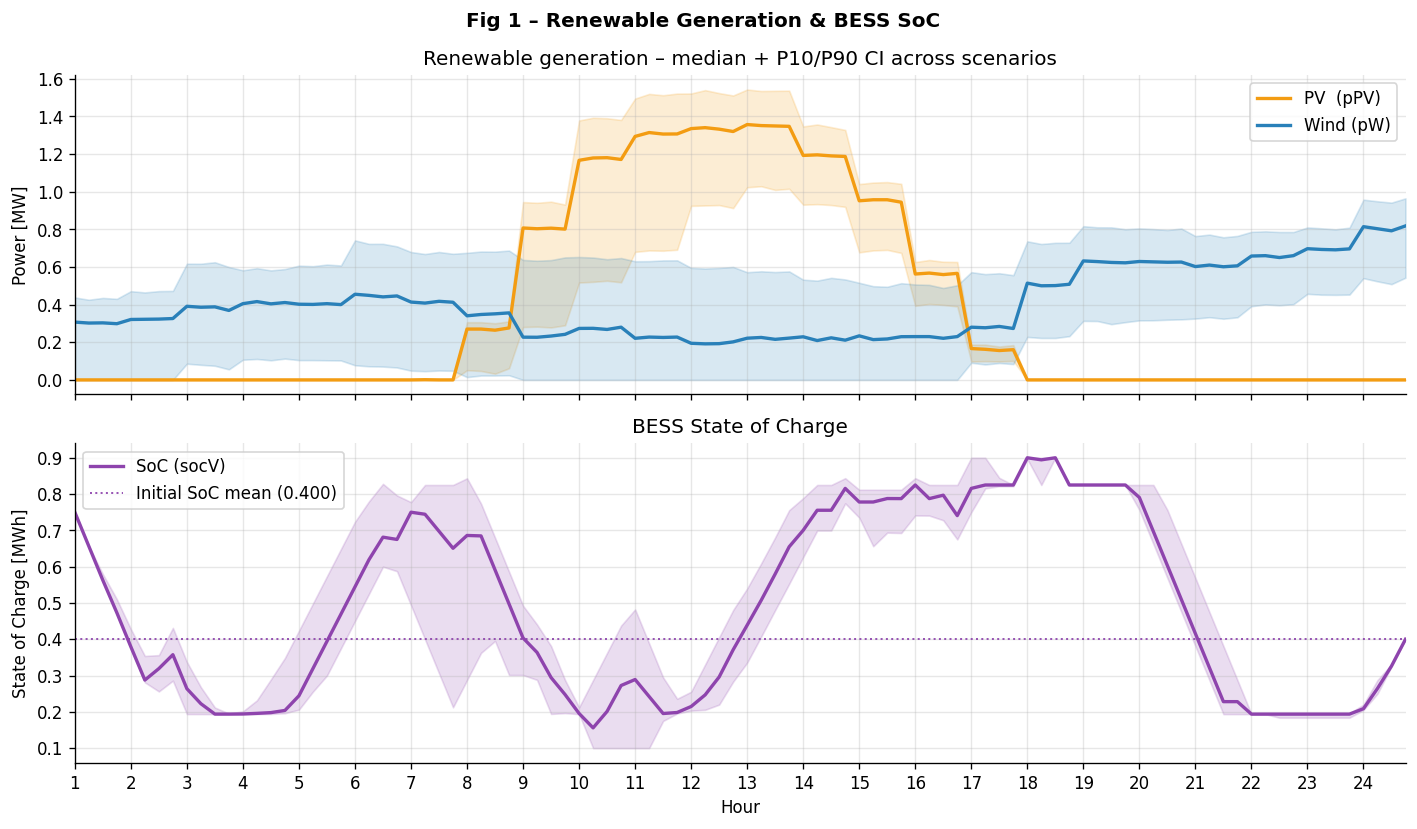

In [65]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 1 – Renewable Generation & BESS SoC", fontweight="bold")
t = _t(next(iter(data.values())))

if "pPV" in data: _band(ax1, t, data["pPV"], COLORS["pv"],   "PV  (pPV)")
if "pW"  in data: _band(ax1, t, data["pW"],  COLORS["wind"], "Wind (pW)")
ax1.set_ylabel("Power [MW]"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Renewable generation – median + P10/P90 CI across scenarios")

if "socV" in data:
    _band(ax2, t, data["socV"], COLORS["bess"], "SoC (socV)")
    _annotate_socv_initial(ax2)
ax2.set_ylabel("State of Charge [MWh]"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("BESS State of Charge")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig1_generation"); plt.show()


## 5 · Fig 2 – BESS Operation (cV_dV & idV)

**What to look for:**
- `cV_dV > 0` → BESS is charging; `< 0` → discharging. Diverging colours make this instant to read.
- `idV` bar height → in what fraction of scenarios is the BESS actually dispatched to discharge at that hour.
- Discrepancy between median `cV_dV < 0` and low `idV` → some scenarios charge while others discharge (high uncertainty in dispatch decision).


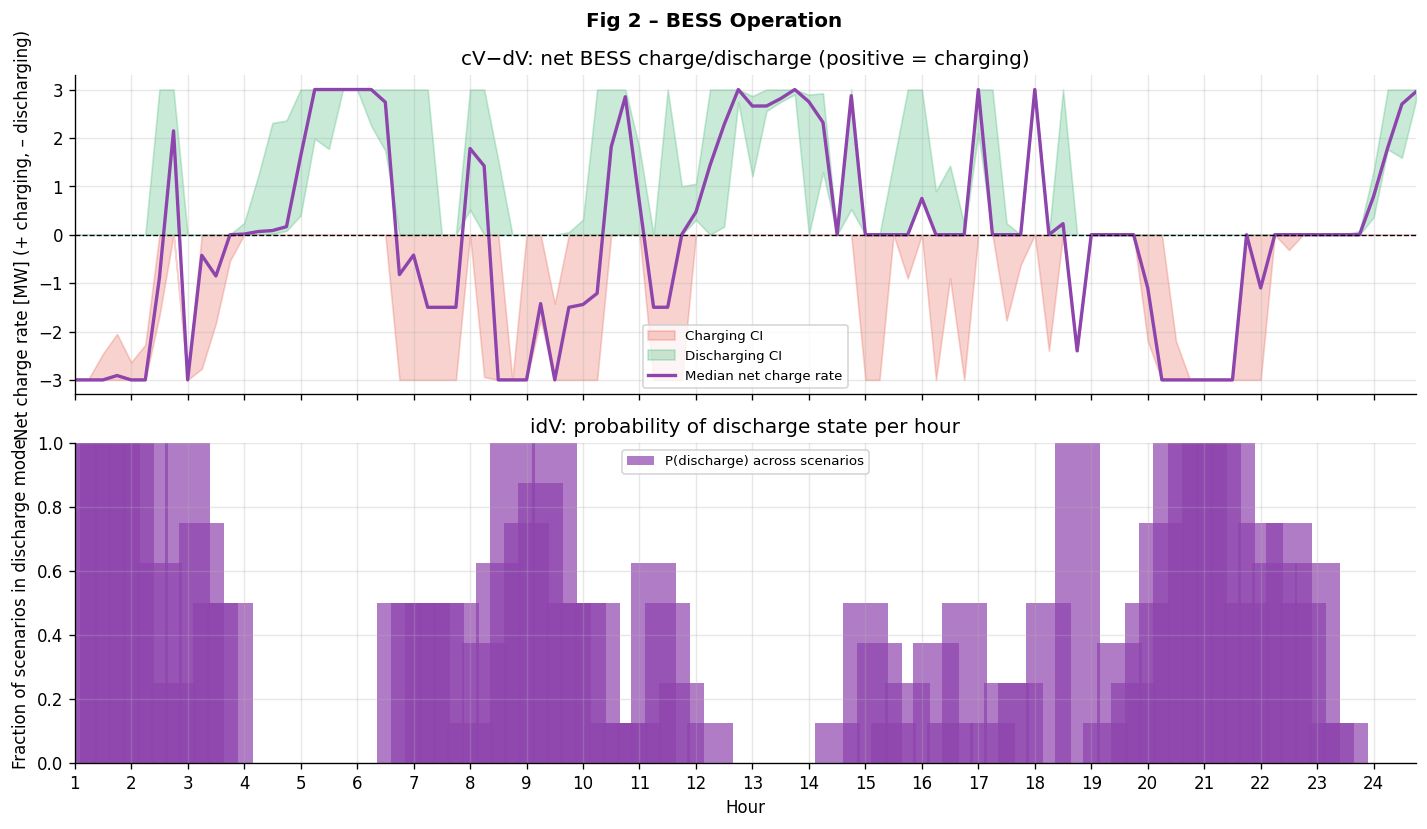

In [68]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 2 – BESS Operation", fontweight="bold")
t = _t(next(iter(data.values())))

if "cV_dV" in data:
    med, lo, hi = _ci(data["cV_dV"])
    ax1.fill_between(t, np.minimum(lo,0), np.minimum(hi,0), color=COLORS["neg"], alpha=0.25, label="Charging CI")
    ax1.fill_between(t, np.maximum(lo,0), np.maximum(hi,0), color=COLORS["pos"], alpha=0.25, label="Discharging CI")
    ax1.plot(t, med, color=COLORS["bess"], lw=2, label="Median net charge rate")
    ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("Net charge rate [MW] (+ charging, – discharging)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("cV−dV: net BESS charge/discharge (positive = charging)")

if "idV" in data:
    ax2.bar(t, data["idV"].mean(axis=1), color=COLORS["bess"], alpha=0.7, label="P(discharge) across scenarios")
    ax2.set_ylim(0,1)
    ax2.set_ylabel("Fraction of scenarios in discharge mode")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
    ax2.set_title("idV: probability of discharge state per hour")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig2_bess_operation"); plt.show()


## 6 · Fig 3 – Flexible Demand

**What to look for:**
- Panel (a): total `var_fd` — does the EC smooth its demand effectively?
- Panel (b): mirrored `var_afd_p` / `var_afd_m` — are both shifts active simultaneously (arbitrage) or mutually exclusive?
- Panel (c): boxplot of **net shift** — wide boxes indicate high scenario uncertainty in how the FD is used. Outliers suggest extreme activation events.


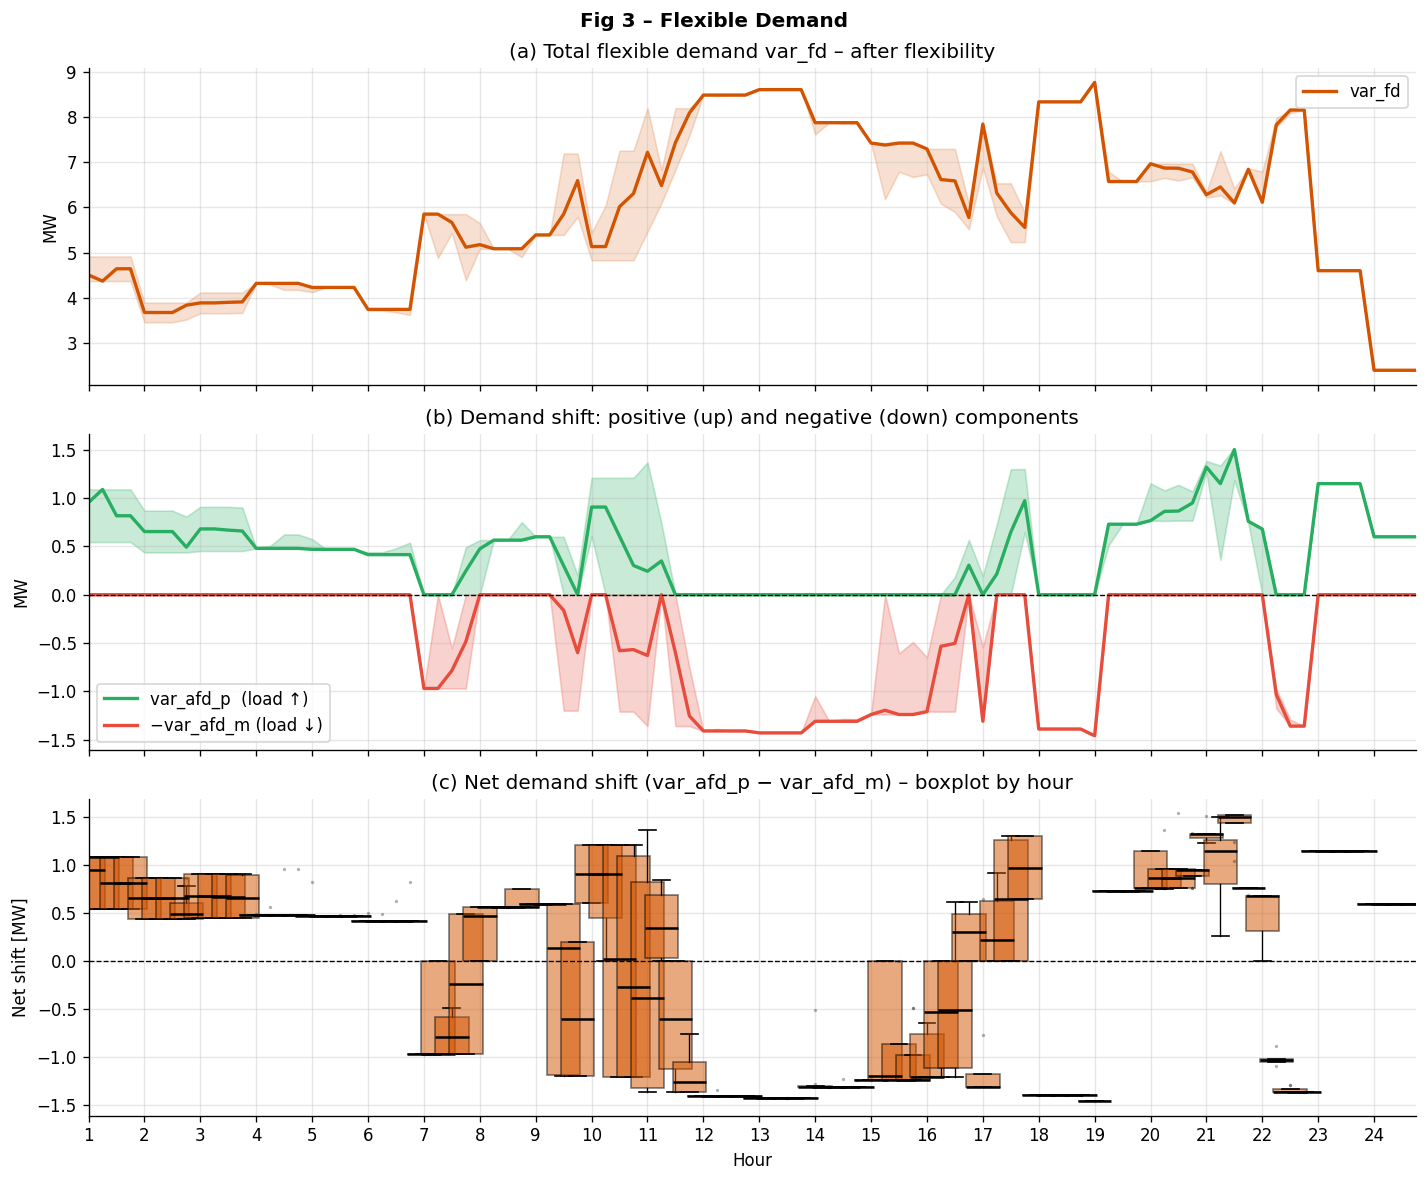

In [69]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 3 – Flexible Demand", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) total flexible demand
if "var_fd" in data:
    _band(ax1, t, data["var_fd"], COLORS["fd"], "var_fd")
ax1.set_ylabel("MW"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("(a) Total flexible demand var_fd – after flexibility")

# (b) positive / negative shifts mirrored
if "var_afd_p" in data and "var_afd_m" in data:
    med_p, lp, hp = _ci(data["var_afd_p"])
    med_m, lm, hm = _ci(data["var_afd_m"])
    ax2.fill_between(t,  lp,  hp, color=COLORS["pos"], alpha=0.25)
    ax2.plot(t, med_p, color=COLORS["pos"], lw=2, label="var_afd_p  (load ↑)")
    ax2.fill_between(t, -hm, -lm, color=COLORS["neg"], alpha=0.25)
    ax2.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−var_afd_m (load ↓)")
    ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_ylabel("MW"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("(b) Demand shift: positive (up) and negative (down) components")

# (c) net shift boxplot per hour
if "var_afd_p" in data and "var_afd_m" in data:
    net = (data["var_afd_p"] - data["var_afd_m"]).values
    ax3.boxplot([net[i,:] for i in range(len(t))],
                positions=t, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor=COLORS["fd"], alpha=0.5),
                medianprops=dict(color="k", lw=1.5),
                whiskerprops=dict(lw=0.8),
                flierprops=dict(marker=".", ms=2, alpha=0.3))
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("Net shift [MW]"); ax3.grid(alpha=0.3)
ax3.set_title("(c) Net demand shift (var_afd_p − var_afd_m) – boxplot by hour")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig3_flexible_demand"); plt.show()


## 7 · Fig 4 – Day-Ahead Commitment 
**What to look for:**
- **Panel (a):** committed energy in DA
- **Panel (b):** commited energy in RM
- **Panel (c):** commited energy in IM1
- **Panel (d):** commited energy in IM2
- **Panel (e):** commited energy in IM3


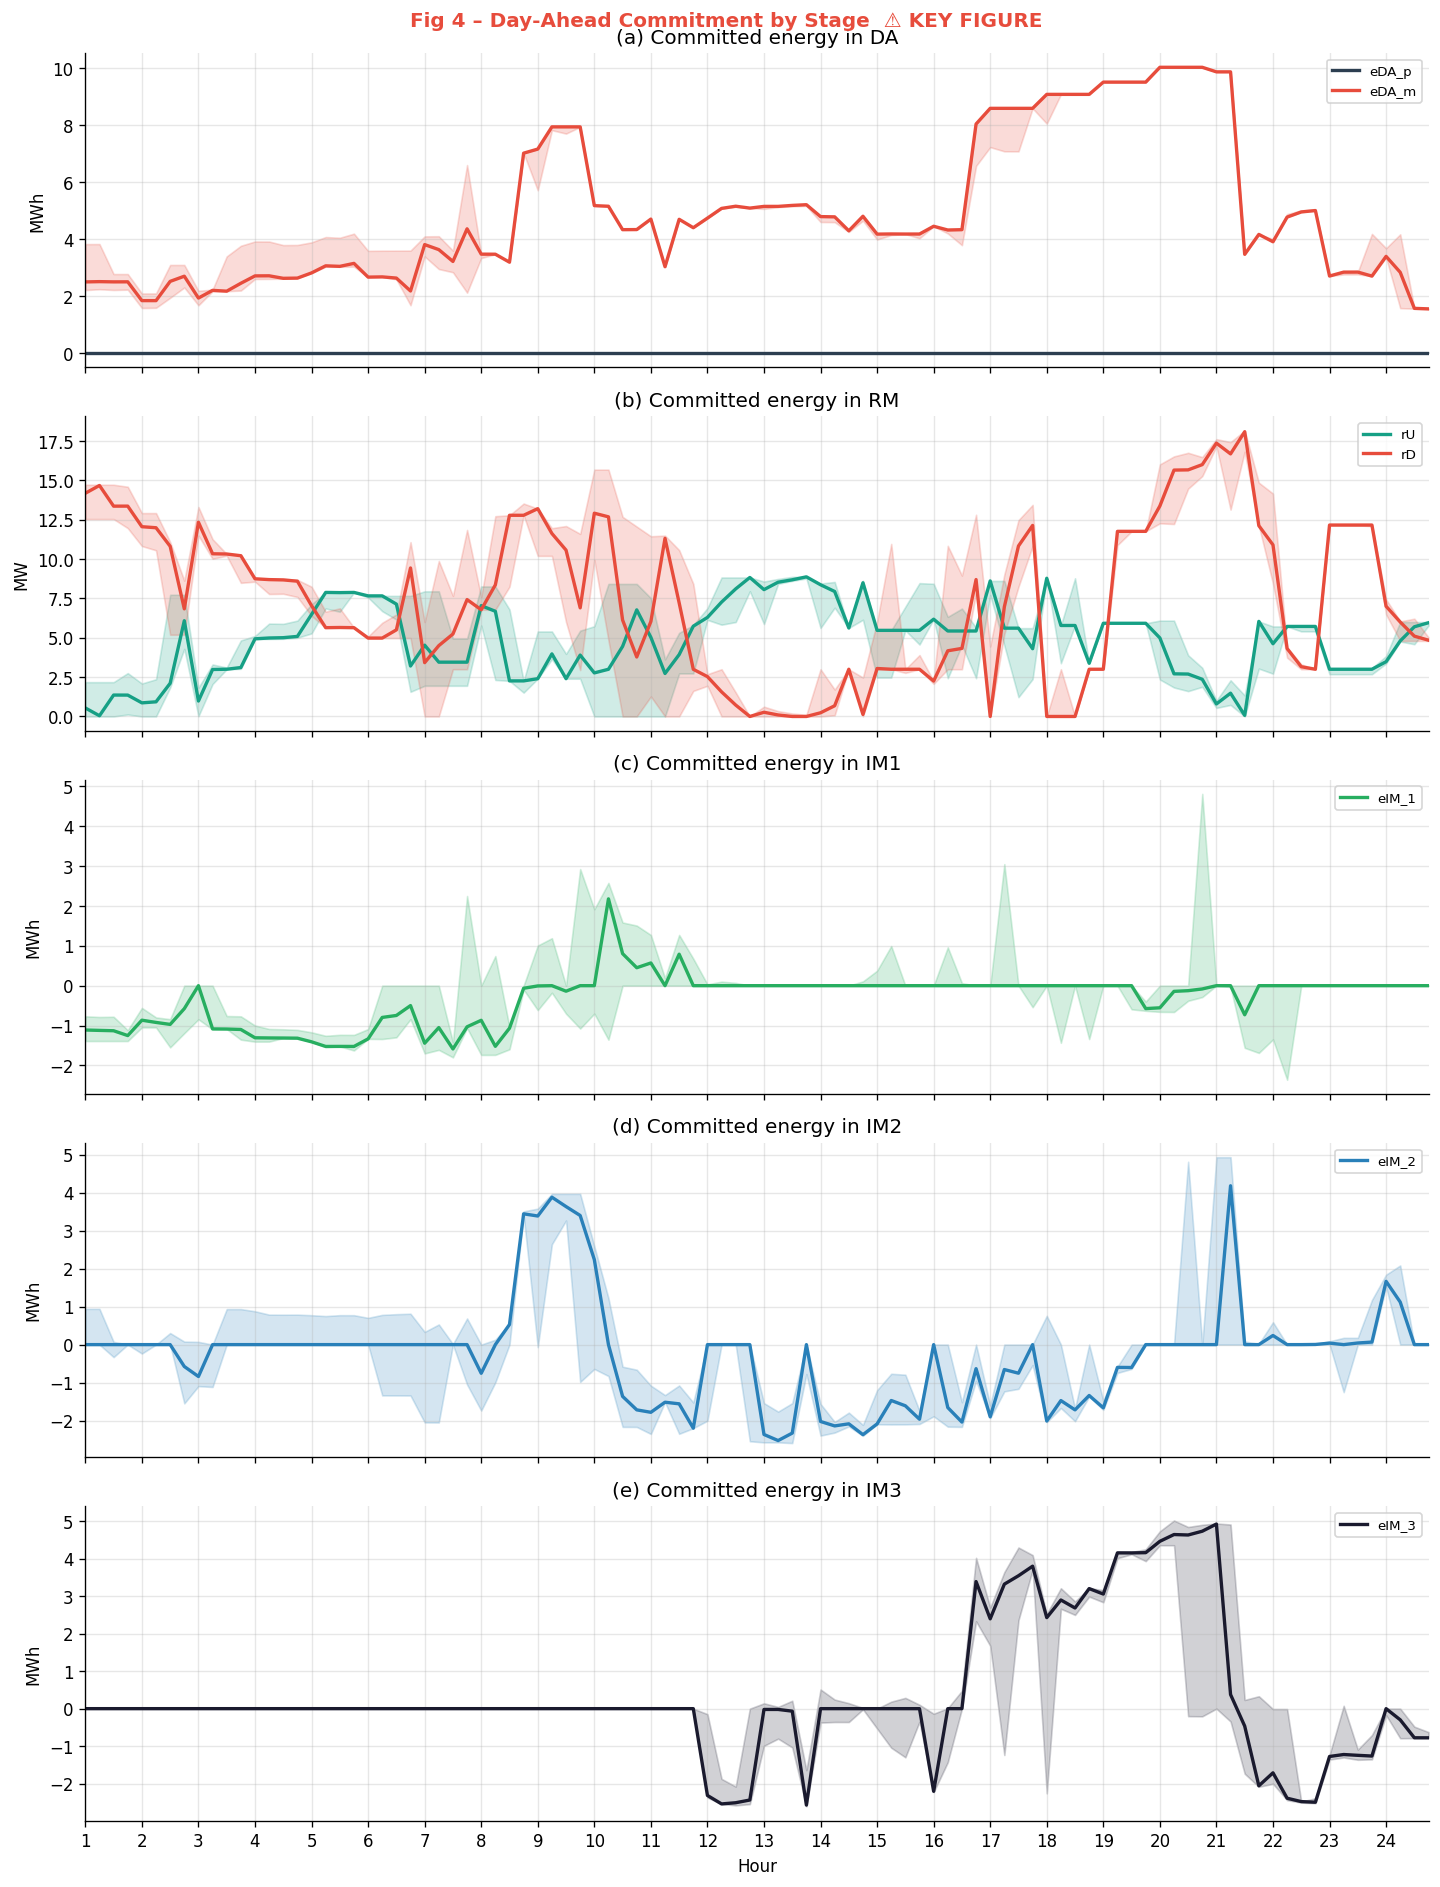

In [70]:
fig, axs = plt.subplots(5, 1, figsize=(12,16), sharex=True)
fig.suptitle("Fig 4 – Day-Ahead Commitment by Stage  ⚠️ KEY FIGURE",
             fontweight="bold", color=COLORS["neg"])
t = _t(next(iter(data.values())))

# (a) committed energy in DA
if "eDA_p" in data:
    med, lo, hi = _ci(data["eDA_p"])
    axs[0].fill_between(t, lo, hi, color=COLORS["da"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["da"], label="eDA_p")
if "eDA_m" in data:
    med, lo, hi = _ci(data["eDA_m"])
    axs[0].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["neg"], label="eDA_m")
axs[0].set_ylabel("MWh"); axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)
axs[0].set_title("(a) Committed energy in DA")

# (b) committed energy in RM
if "rU" in data:
    med, lo, hi = _ci(data["rU"])
    axs[1].fill_between(t, lo, hi, color=COLORS["reserve"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["reserve"], label="rU")
if "rD" in data:
    med, lo, hi = _ci(data["rD"])
    axs[1].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["neg"], label="rD")
axs[1].set_ylabel("MW"); axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
axs[1].set_title("(b) Committed energy in RM")

# (c) committed energy in IM1
if "eIM_1" in data:
    med, lo, hi = _ci(data["eIM_1"])
    axs[2].fill_between(t, lo, hi, color=COLORS["pos"], alpha=0.2)
    axs[2].plot(t, med, lw=2, color=COLORS["pos"], label="eIM_1")
axs[2].set_ylabel("MWh"); axs[2].legend(fontsize=8); axs[2].grid(alpha=0.3)
axs[2].set_title("(c) Committed energy in IM1")

# (d) committed energy in IM2
if "eIM_2" in data:
    med, lo, hi = _ci(data["eIM_2"])
    axs[3].fill_between(t, lo, hi, color=COLORS["wind"], alpha=0.2)
    axs[3].plot(t, med, lw=2, color=COLORS["wind"], label="eIM_2")
axs[3].set_ylabel("MWh"); axs[3].legend(fontsize=8); axs[3].grid(alpha=0.3)
axs[3].set_title("(d) Committed energy in IM2")

# (e) committed energy in IM3
if "eIM_3" in data:
    med, lo, hi = _ci(data["eIM_3"])
    axs[4].fill_between(t, lo, hi, color=COLORS["median"], alpha=0.2)
    axs[4].plot(t, med, lw=2, color=COLORS["median"], label="eIM_3")
axs[4].set_ylabel("MWh"); axs[4].legend(fontsize=8); axs[4].grid(alpha=0.3)
axs[4].set_title("(e) Committed energy in IM3")
axs[4].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axs[4], t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig4_da_commitment"); plt.show()

## 8 · Fig 5 – Reserve Provision (Upward & Downward)

**What to look for:**
- Which asset (BESS vs FD) carries the bulk of reserve provision at each hour.
- Dashed total line vs. stacked area → if total > BESS + FD something is off (data check).
- Wide CI on the total reserve → significant scenario uncertainty in reserve matching.


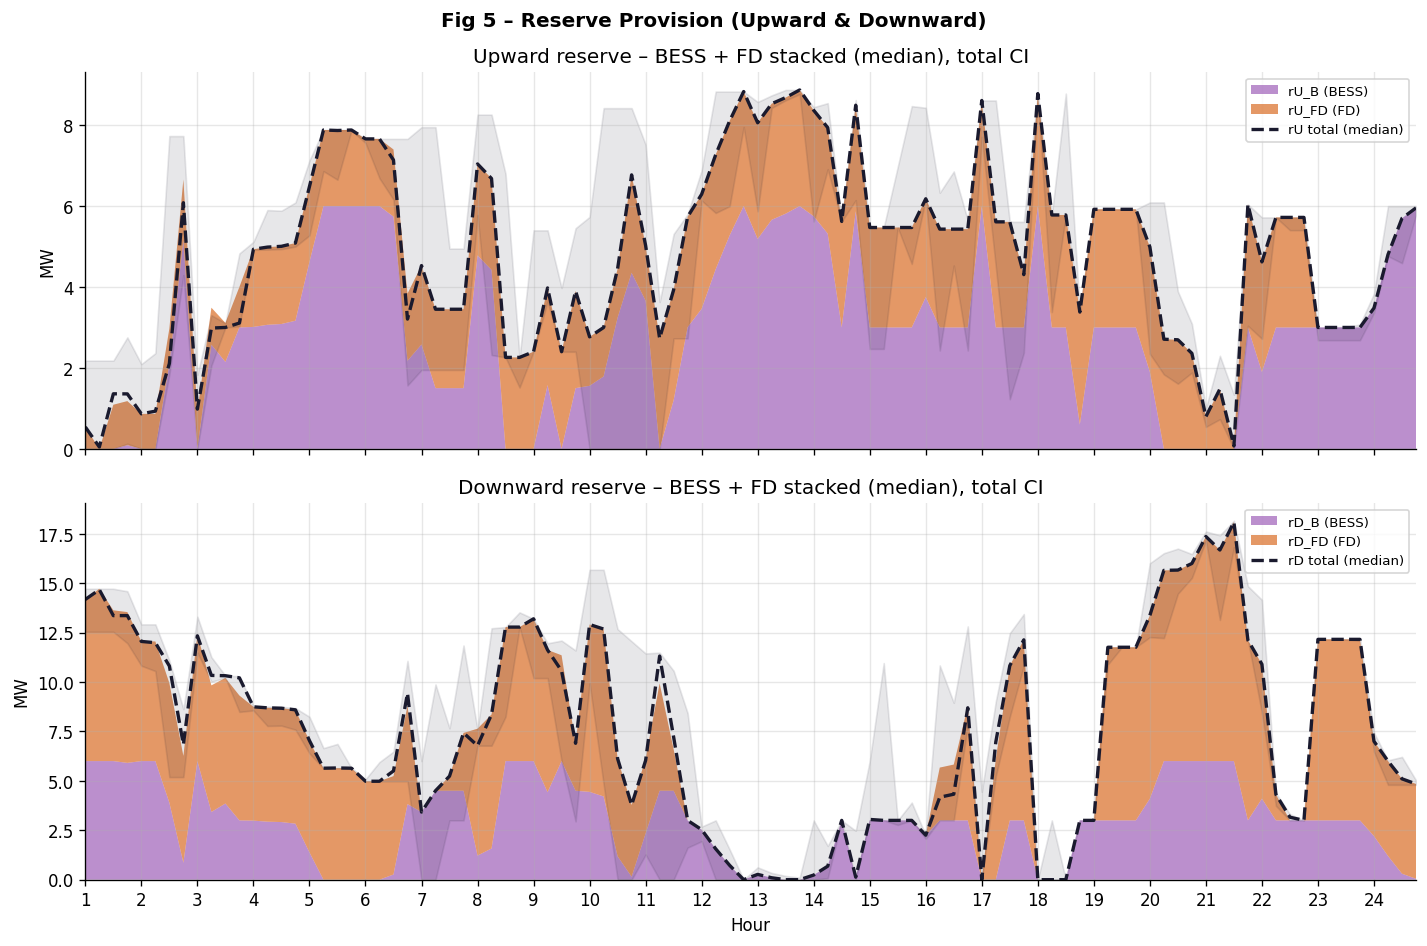

In [71]:
fig, (ax_u, ax_d) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
fig.suptitle("Fig 5 – Reserve Provision (Upward & Downward)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, label, r_tot, r_b, r_fd in [
    (ax_u, "Upward",   "rU",  "rU_B",  "rU_FD"),
    (ax_d, "Downward", "rD",  "rD_B",  "rD_FD"),
]:
    med_b  = data[r_b ].median(axis=1).values if r_b  in data else np.zeros(len(t))
    med_fd = data[r_fd].median(axis=1).values if r_fd in data else np.zeros(len(t))
    ax.stackplot(t, med_b, med_fd,
                 labels=[f"{r_b} (BESS)", f"{r_fd} (FD)"],
                 colors=[COLORS["bess"], COLORS["fd"]], alpha=0.6)
    if r_tot in data:
        med_tot, lo, hi = _ci(data[r_tot])
        ax.plot(t, med_tot, color=COLORS["median"], lw=2, ls="--",
                label=f"{r_tot} total (median)")
        ax.fill_between(t, lo, hi, color=COLORS["median"], alpha=0.1)
    ax.set_ylabel("MW"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f"{label} reserve – BESS + FD stacked (median), total CI")

ax_d.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax_d, t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig5_reserves"); plt.show()


## 9 · Fig 6 – Imbalance & Intraday Position ⚠️ KEY FIGURE

**What to look for:**
- **Panel (a):** mirrored pIB_p / pIB_m — does the EC mostly over-deliver or under-deliver?
- **Panel (b):** net imbalance bars — red hours = under-delivery (penalty exposure); green = over-delivery (spill or revenue).
- **Panel (c):** `eIM` — does intraday trading reduce imbalance at the same hours where panel (b) is red? If yes, the intraday market is effective.


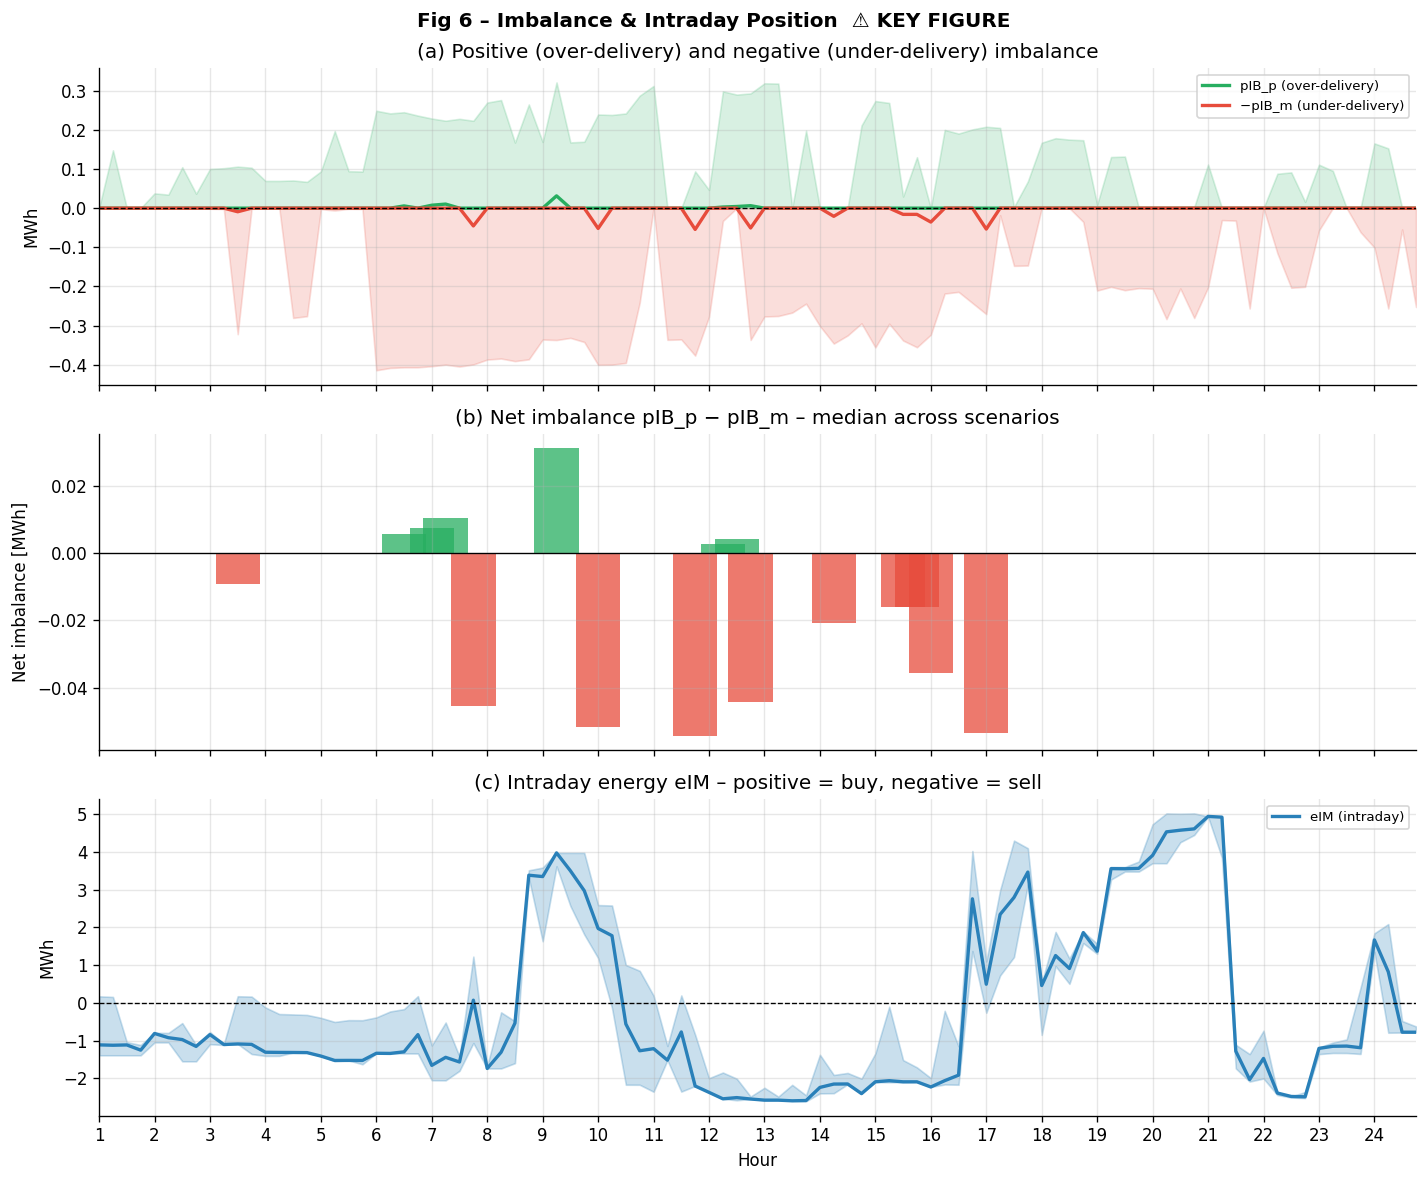

In [72]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 6 – Imbalance & Intraday Position  ⚠️ KEY FIGURE", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) pIB_p / pIB_m mirrored
if "pIB_p" in data:
    _band(ax1, t, data["pIB_p"], COLORS["pos"], "pIB_p (over-delivery)")
if "pIB_m" in data:
    med_m, lo_m, hi_m = _ci(data["pIB_m"])
    ax1.fill_between(t, -hi_m, -lo_m, color=COLORS["neg"], alpha=0.18)
    ax1.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−pIB_m (under-delivery)")
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("MWh"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("(a) Positive (over-delivery) and negative (under-delivery) imbalance")

# (b) net imbalance bar
if "pIB_p" in data and "pIB_m" in data:
    net_med = (data["pIB_p"] - data["pIB_m"]).median(axis=1).values
    ax2.bar(t, net_med, color=[COLORS["pos"] if v>=0 else COLORS["neg"] for v in net_med], alpha=0.75)
    ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Net imbalance [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Net imbalance pIB_p − pIB_m – median across scenarios")

# (c) eIM intraday
if "eIM" in data:
    med_im, lo_im, hi_im = _ci(data["eIM"])
    ax3.fill_between(t, lo_im, hi_im, color=COLORS["wind"], alpha=0.25)
    ax3.plot(t, med_im, color=COLORS["wind"], lw=2, label="eIM (intraday)")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("MWh"); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.set_title("(c) Intraday energy eIM – positive = buy, negative = sell")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig6_imbalance"); plt.show()


## 10 · Fig 7 – Scenario Fan Charts (spaghetti)

**What to look for:**
- Are traces clustered (low spread) or spread widely (high uncertainty)?
- Bimodal shapes → two distinct operating regimes across scenarios.
- Extreme outlier traces → which scenario drives the worst case?

> You can change `vars_to_show` to inspect any subset of variables.


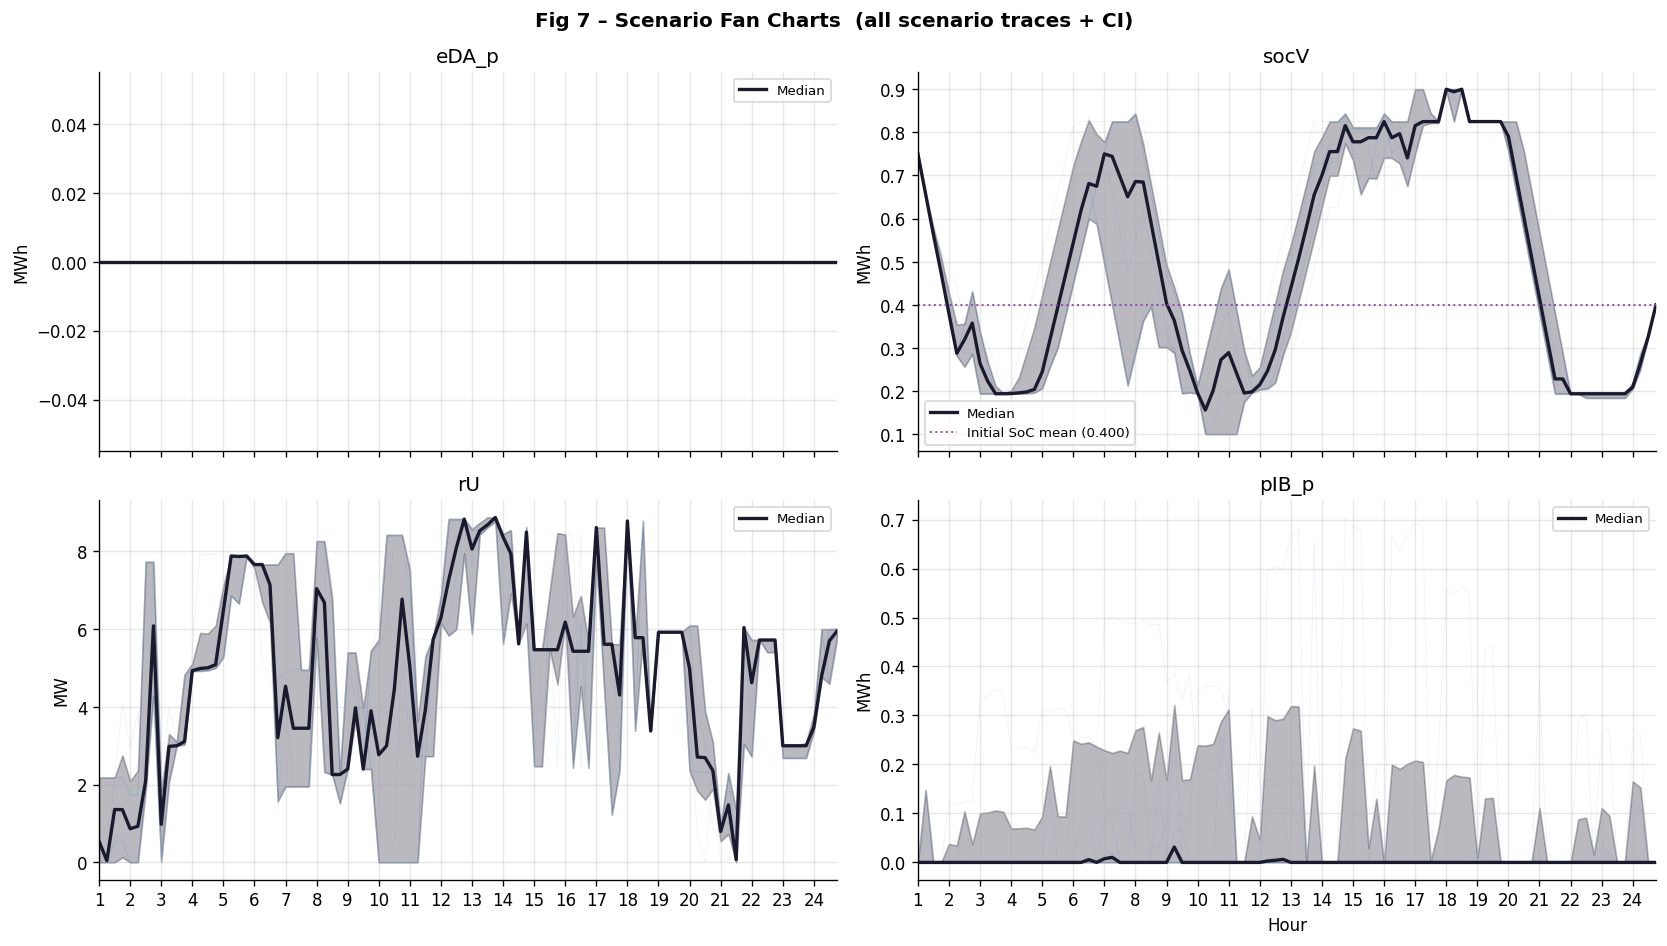

In [73]:
vars_to_show = ["eDA_p", "socV", "rU", "pIB_p"]   # ← edit here
vars_to_show = [v for v in vars_to_show if v in data]

ncols = 2
nrows = int(np.ceil(len(vars_to_show)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=True)
axes = np.array(axes).flatten()
fig.suptitle("Fig 7 – Scenario Fan Charts  (all scenario traces + CI)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, var in zip(axes, vars_to_show):
    df = data[var]
    for col in df.columns:
        ax.plot(t, df[col].values, color=COLORS["ci_fill"], lw=0.4, alpha=0.12)
    _band(ax, t, df, COLORS["median"], "Median", alpha=0.3)
    if var == "socV":
        _annotate_socv_initial(ax)
    ax.set_title(var); ax.set_ylabel(UNITS.get(var,"–")); ax.grid(alpha=0.3); ax.legend(fontsize=8)

for ax in axes[len(vars_to_show):]: ax.set_visible(False)
axes[-1].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axes[-1], t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig7_scenario_fans"); plt.show()


## 11 ? Market Benefit Distribution

Boxplot of total scenario benefit by market. CI markers show P10-P90 across scenarios.


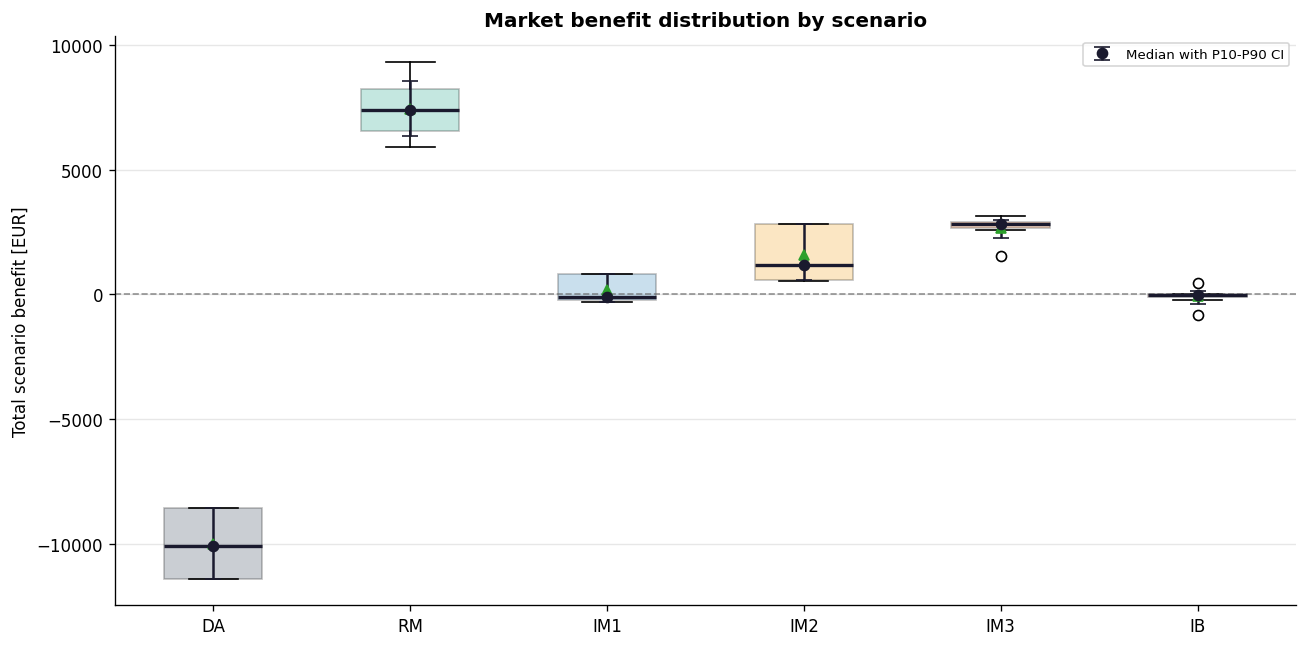

,median,P10,P90,mean
DA,-10118.2584,-11441.7118,-8566.6444,-10032.6982
RM,7379.5130,6345.9042,8554.8283,7438.2309
IM1,-122.5986,-295.5108,823.5497,177.1246
IM2,1156.2790,548.3644,2829.3035,1555.4749
IM3,2825.3105,2264.8245,2992.5480,2671.9692
IB,-23.8507,-412.9635,140.3826,-88.3533


In [74]:
def _aligned_product_total(*dfs):
    dfs = [df for df in dfs if df is not None]
    if not dfs:
        return None
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    if len(common_index) == 0 or len(common_cols) == 0:
        return None
    prod = dfs[0].loc[common_index, common_cols].copy()
    for df in dfs[1:]:
        prod = prod * df.loc[common_index, common_cols]
    return prod.sum(axis=0)

market_benefits = {}

if {"lD", "eDA_p", "eDA_m"}.issubset(data):
    da_net = data["eDA_p"] - data["eDA_m"]
    market_benefits["DA"] = _aligned_product_total(data["lD"], da_net)

if {"lR", "rU", "rD"}.issubset(data):
    rm_reserve = data["rU"] + data["rD"]
    market_benefits["RM"] = _aligned_product_total(data["lR"], rm_reserve)

for i in [1, 2, 3]:
    li = f"lI_{i}"
    ei = f"eIM_{i}"
    if {li, ei}.issubset(data):
        market_benefits[f"IM{i}"] = _aligned_product_total(data[li], data[ei])

if {"lPIB", "pIB_p", "lNIB", "pIB_m"}.issubset(data):
    ib_income = _aligned_product_total(data["lPIB"], data["pIB_p"])
    ib_costs = _aligned_product_total(data["lNIB"], data["pIB_m"])
    if ib_income is not None and ib_costs is not None:
        common_cols = ib_income.index.intersection(ib_costs.index)
        market_benefits["IB"] = ib_income.loc[common_cols] - ib_costs.loc[common_cols]

market_order = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
market_benefits = {k: market_benefits[k].dropna() for k in market_order if k in market_benefits and market_benefits[k] is not None}

if not market_benefits:
    print("No market benefit data available for this run.")
else:
    labels = list(market_benefits.keys())
    values = [market_benefits[k].values for k in labels]
    positions = np.arange(1, len(labels) + 1)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bp = ax.boxplot(values, positions=positions, labels=labels, patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], [COLORS["da"], COLORS["reserve"], COLORS["wind"], COLORS["pv"], COLORS["fd"], COLORS["imbal"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for med in bp["medians"]:
        med.set_color(COLORS["median"])
        med.set_linewidth(2)

    ci_low, ci_high = CONFIG["ci_low"], CONFIG["ci_high"]
    medians = np.array([np.median(v) for v in values])
    lo = np.array([np.percentile(v, ci_low) for v in values])
    hi = np.array([np.percentile(v, ci_high) for v in values])
    ax.errorbar(positions, medians, yerr=[medians - lo, hi - medians], fmt="o",
                color=COLORS["median"], ecolor=COLORS["median"], capsize=5,
                label=f"Median with P{ci_low}-P{ci_high} CI")
    ax.axhline(0, color="#666666", lw=1, ls="--", alpha=0.7)
    ax.set_ylabel("Total scenario benefit [EUR]")
    ax.set_title("Market benefit distribution by scenario", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout(); _save(fig, "fig_market_benefits_boxplot"); plt.show()

    benefit_summary = pd.DataFrame({
        "median": medians,
        f"P{ci_low}": lo,
        f"P{ci_high}": hi,
        "mean": [np.mean(v) for v in values],
    }, index=labels)
    display(benefit_summary)


## 11 · Fig 8 – Correlation Heatmap

**What to look for:**
- Strong positive correlation (dark blue) between PV/Wind and reserve/FD → renewable surplus drives reserve provision.
- Strong negative correlation between `socV` and `pIB_m` → better SoC management reduces imbalance penalties.
- Any unexpected high correlation that reveals hidden structural coupling in the model.


Excluded constant variables from correlation heatmap: ['eDA_p', 'ieDA_m', 'ieDA_p']
Correlation heatmap uses 30 operational variables with shared index 96 time points.


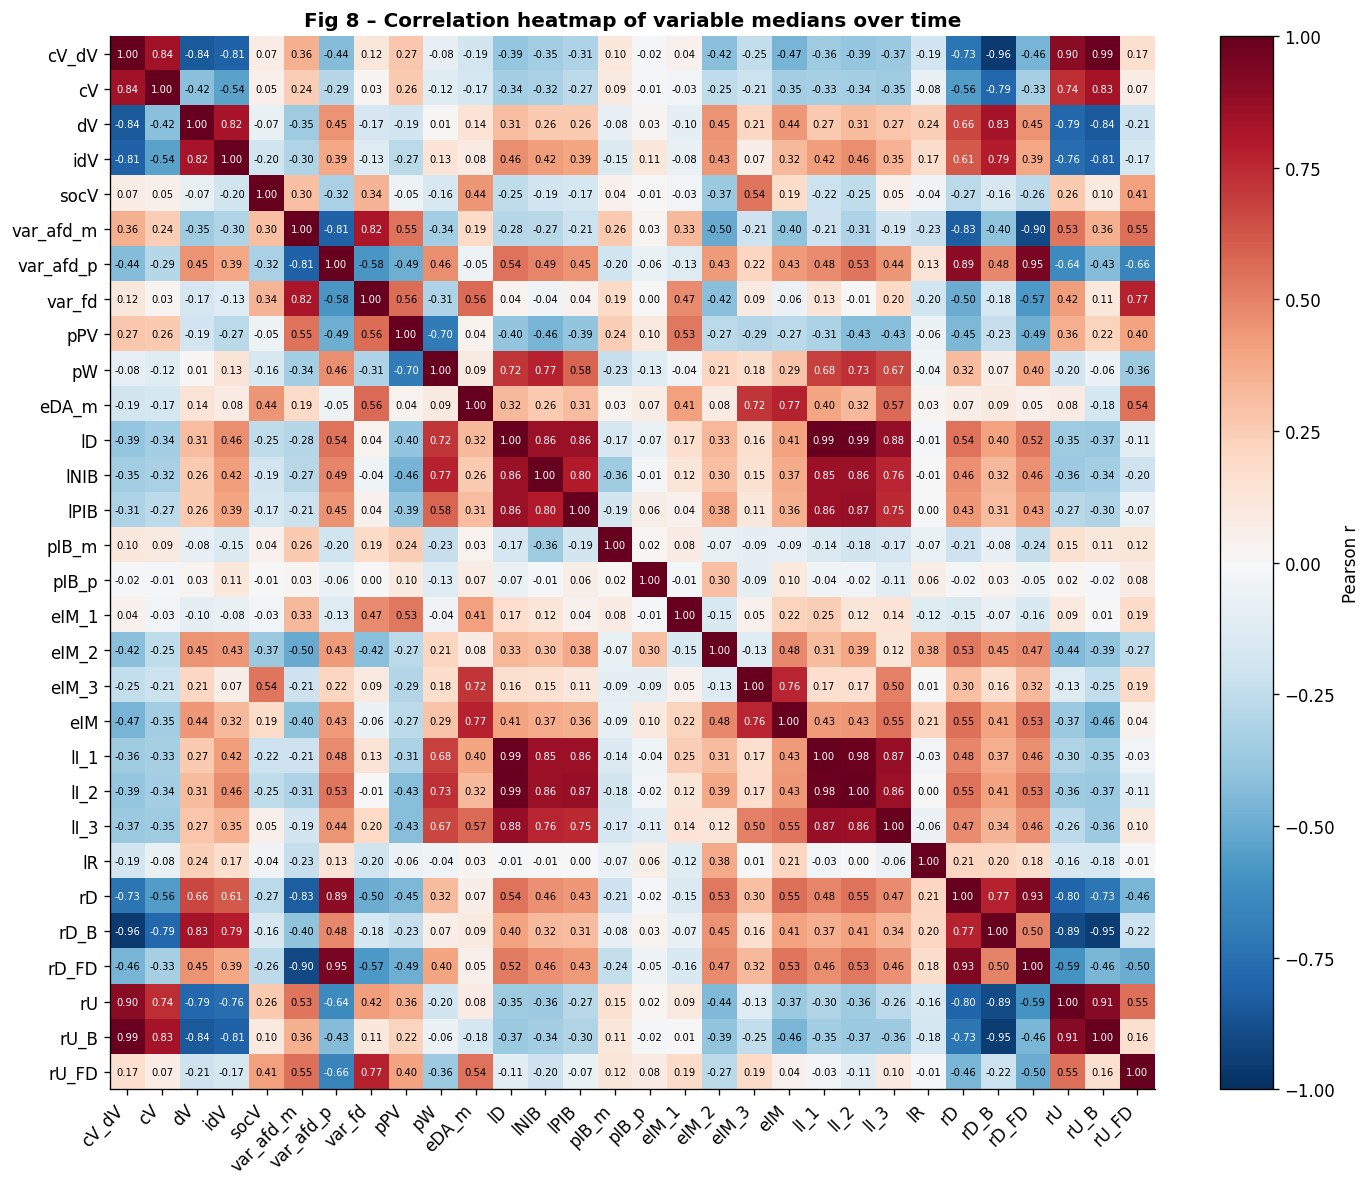

In [75]:
op_data = _operational_ts_data(data)
med_df = pd.DataFrame({v: df.median(axis=1) for v, df in op_data.items()})
empty_vars = med_df.columns[med_df.isna().all()].tolist()
if empty_vars:
    print("Dropped empty variables from correlation heatmap:", empty_vars)
med_df = med_df.dropna(axis=1, how="all")
std = med_df.std(axis=0)
constant_vars = std[std <= 1e-12].index.tolist()
if constant_vars:
    print("Excluded constant variables from correlation heatmap:", constant_vars)
med_df = med_df.loc[:, std > 1e-12]
corr = med_df.corr(min_periods=2)
if corr.isna().any().any():
    print("Warning: correlation contains NaN values due to insufficient data for some variable pairs. NaN values are preserved.")
print(f"Correlation heatmap uses {med_df.shape[1]} operational variables with shared index {med_df.shape[0]} time points.")

fig, ax = plt.subplots(figsize=(12,10))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d3d3d3")
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i,j]
        text = f"{val:.2f}" if not np.isnan(val) else "NaN"
        color = "white" if not np.isnan(val) and abs(val) > 0.6 else "black"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=6, color=color)
ax.set_title("Fig 8 – Correlation heatmap of variable medians over time", fontweight="bold")
plt.tight_layout(); _save(fig, "fig8_correlation"); plt.show()


## 12 · Fig 9 – Commitment Failure Dashboard ⚠️ KEY FIGURE

One-page answer to *"when and how severely did the EC miss its day-ahead commitments?"*

| Sub-panel | What it shows |
|---|---|
| **(a) Risk strip** | colour = fraction of scenarios with `pIB_m > 0`; red hours = most risky |
| **(b) Shortfall bars** | median magnitude of `pIB_m` (CI band) |
| **(c) Delivered power** | actual delivered power from `pPV + pW - cV_dV` when available; otherwise show `pIB_m` under-delivery proxy |
| **(d) CDF** | cumulative distribution of total daily under-delivery across all scenarios; P90 marks the tail risk |


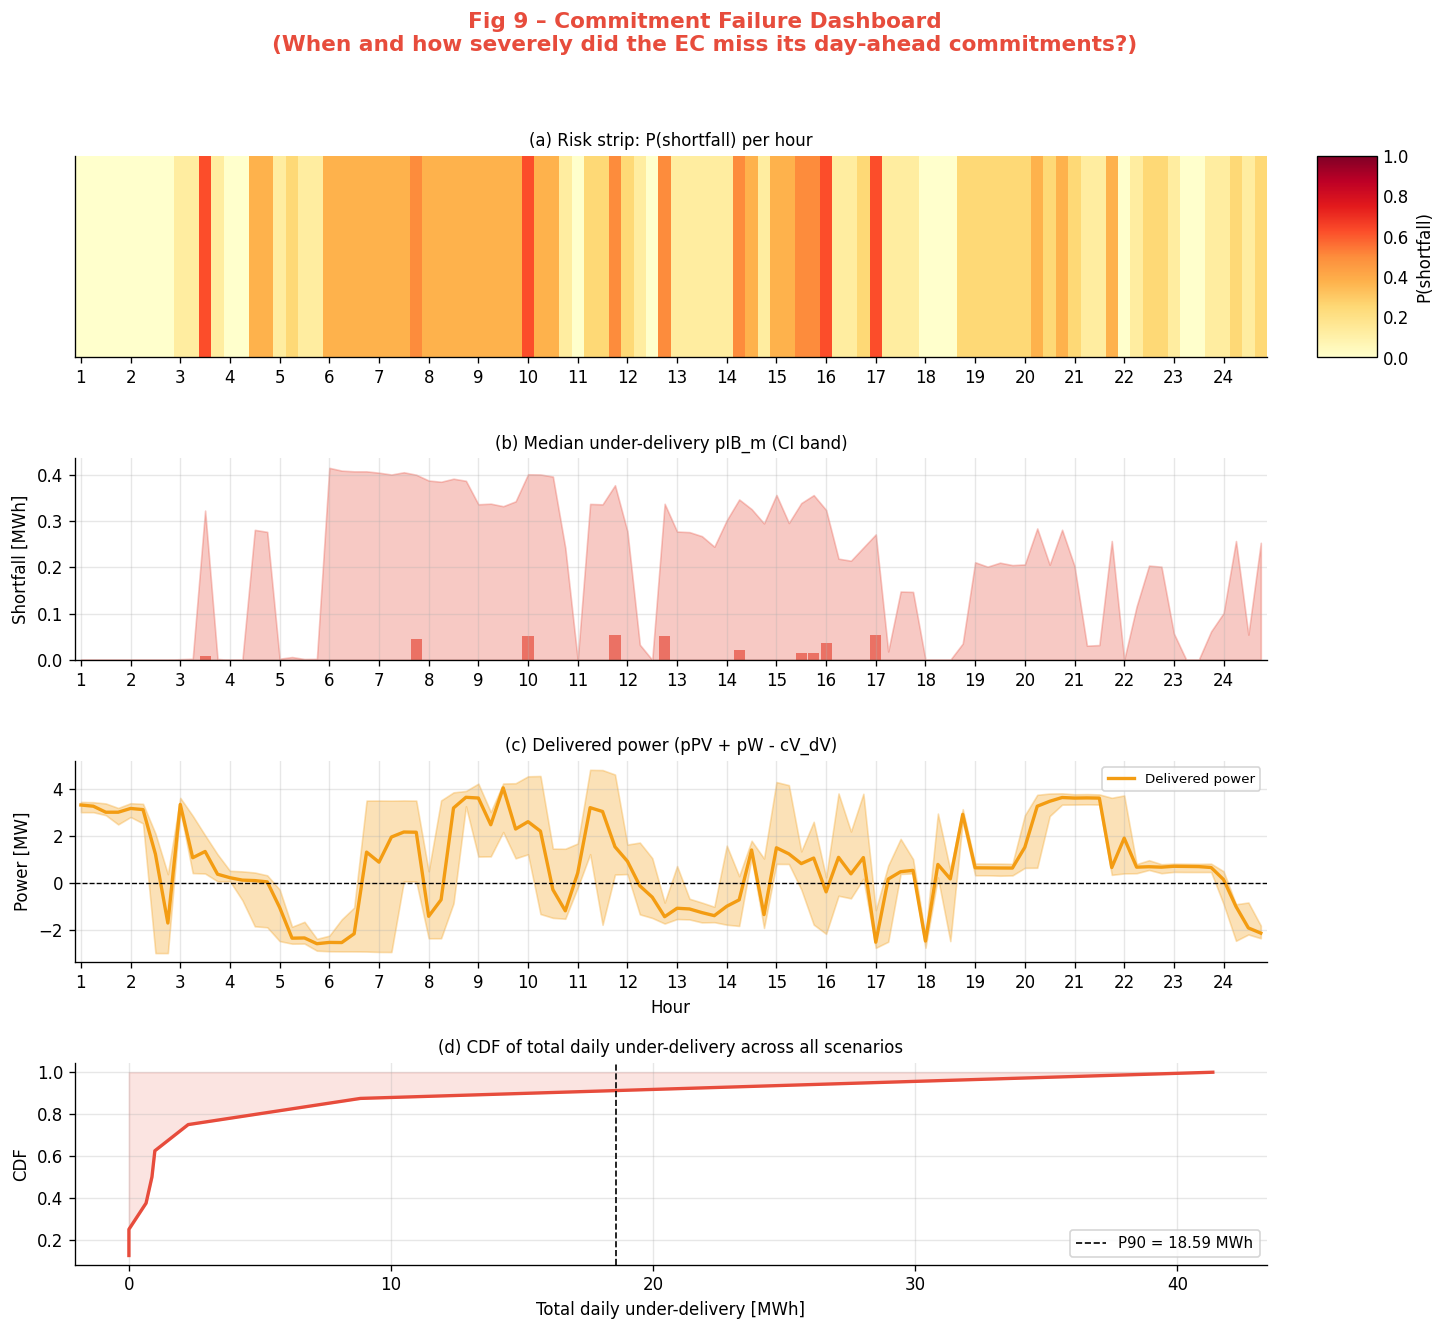

In [83]:
fig = plt.figure(figsize=(14,12))
fig.suptitle("Fig 9 – Commitment Failure Dashboard\n"
             "(When and how severely did the EC miss its day-ahead commitments?)",
             fontweight="bold", color=COLORS["neg"], fontsize=13)

gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], wspace=0.08, hspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0])

t_arr = _t(next(iter(data.values())))
T = len(t_arr)
step = float(np.min(np.diff(t_arr))) if len(t_arr) > 1 else 1.0
x_edges = np.concatenate([t_arr - step/2, [t_arr[-1] + step/2]])
bar_width = min(0.8, step * 0.9)

# (a) risk heat-strip
prob = np.zeros(T)
if "pIB_m" in data:
    prob = (data["pIB_m"] > 1e-6).mean(axis=1).values
heat = ax1.pcolormesh(x_edges, [0, 1], prob[None, :], cmap="YlOrRd",
                      vmin=0, vmax=1, shading="auto")
fig.colorbar(heat, cax=cax, orientation="vertical")
cax.set_ylabel("P(shortfall)")
cax.yaxis.set_label_position("right")
cax.tick_params(axis="both", which="both", length=0)
ax1.set_yticks([])
ax1.set_title("(a) Risk strip: P(shortfall) per hour", fontsize=10)
ax1.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
ax1.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
ax1.set_xlim(x_edges[0], x_edges[-1])

# (b) shortfall bars
if "pIB_m" in data:
    med, lo, hi = _ci(data["pIB_m"])
    ax2.fill_between(t_arr, lo, hi, color=COLORS["neg"], alpha=0.3)
    ax2.bar(t_arr, med, color=COLORS["neg"], alpha=0.7, width=bar_width)
ax2.set_ylabel("Shortfall [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Median under-delivery pIB_m (CI band)", fontsize=10)

# (c) delivered power
if {"pPV", "pW", "cV_dV"}.issubset(data):
    delivered = data["pPV"] + data["pW"] - data["cV_dV"]
    med_del, lo_del, hi_del = _ci(delivered)
    ax3.fill_between(t_arr, lo_del, hi_del, color=COLORS["pv"], alpha=0.3)
    ax3.plot(t_arr, med_del, color=COLORS["pv"], lw=2, label="Delivered power")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
    ax3.set_ylabel("Power [MW]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Delivered power (pPV + pW - cV_dV)", fontsize=10)
else:
    if "pIB_m" in data:
        med_ib, lo_ib, hi_ib = _ci(data["pIB_m"])
        ax3.fill_between(t_arr, lo_ib, hi_ib, color=COLORS["imbal"], alpha=0.3)
        ax3.plot(t_arr, med_ib, color=COLORS["imbal"], lw=2, label="pIB_m median")
    ax3.set_ylabel("pIB_m [MWh]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Negative imbalance pIB_m – proxy for under-delivery cost", fontsize=10)

# (d) CDF of total daily under-delivery
if "pIB_m" in data:
    sf_tot = data["pIB_m"].sum(axis=0).values
    sf_s   = np.sort(sf_tot)
    cdf    = np.arange(1,len(sf_s)+1)/len(sf_s)
    ax4.plot(sf_s, cdf, color=COLORS["neg"], lw=2)
    ax4.fill_betweenx(cdf, 0, sf_s, color=COLORS["neg"], alpha=0.15)
    p90 = np.percentile(sf_s,90)
    ax4.axvline(p90, color="k", ls="--", lw=1, label=f"P90 = {p90:.2f} MWh")
    ax4.set_xlabel("Total daily under-delivery [MWh]")
    ax4.set_ylabel("CDF"); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
    ax4.set_title("(d) CDF of total daily under-delivery across all scenarios", fontsize=10)
else:
    ax4.text(0.5, 0.5, "No pIB_m data available for daily under-delivery CDF",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_axis_off()

_save(fig, "fig9_commitment_dashboard"); plt.show()

## 13 · Export Descriptive Statistics to CSV

In [ ]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    out = os.path.join(CONFIG["fig_dir"], "descriptive_stats.csv")
    summary.to_csv(out)
    print(f"Saved → {out}")
else:
    print("Set CONFIG['save_figs'] = True to export.")
